### Configuration

In [74]:
import os
import sys
from pathlib import Path

os.chdir('/app/models')

CONFIG_PATH="../config.yaml"
ENV_PATH="../.env"
DATASET_PATH="../dataset"
REPORTS_PATH="../reports"
REQUIREMENTS_PATH="../requirements.txt"

current_path = os.getcwd()

PROJECT_ROOT = os.path.join(current_path, '..')

absolute_root = os.path.abspath(PROJECT_ROOT)
if absolute_root not in sys.path:
    sys.path.append(absolute_root)


print(os.getcwd())
if os.path.exists(REQUIREMENTS_PATH):
    print(f"Installing: {REQUIREMENTS_PATH}")
    %pip install -r {REQUIREMENTS_PATH} -q
else:
    print("File requirements.txt not found")
import torch

import shutil
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler, Subset
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import pickle
from enum import IntEnum
import yaml
from dotenv import load_dotenv
from pydantic import BaseModel, Field, field_validator
from pydantic_settings import BaseSettings, SettingsConfigDict
from datetime import datetime
from scipy.spatial.distance import cdist 

# ___ config.yaml schema ___

class Phase_1(BaseModel):
      dropout_rate: float = Field(ge=0, le=1)
class Phase_2(BaseModel):
      dropout_rate: float = Field(ge=0, le=1)
      hidden_dim: int
      num_layers: int

class ModelParams(BaseModel):
    phase_1: Phase_1
    phase_2: Phase_2

class TrainingParams(BaseModel):
    num_epochs: int = Field(gt=0)
    batch_size: int = Field(gt=0)
    learning_rate: float = Field(gt=0)
    checkpoint_interval: int
    patience: int
    load_checkpoint: bool
    use_scheduler: bool

class DataParams(BaseModel):
    train_split: float
    val_split: float
    gaussian_noise_mean: float
    gaussian_noise_std: float
    min_scale: float
    max_scale: float
    occlusion_prob: float
    blind_distance_value: float
    window_size: int

class FullConfig(BaseModel):
    model: ModelParams
    training: TrainingParams
    data: DataParams


# ___ .env schema ___

class EnvSettings(BaseSettings):
    checkpoint_path: Path
    device: str

    use_colab: bool = False
    colab_dataset_zip_path: str | None = None
    colab_dataset_target_path: str | None = None

    model_config = SettingsConfigDict(env_file=ENV_PATH, extra="ignore")

    @field_validator("device")
    @classmethod
    def validate_torch_device(cls, d: str) -> str:
        d = d.lower().strip()
        if d == "cuda":
            if not torch.cuda.is_available():
                raise ValueError(f"""torch couldn't find device 'cuda' required by '{cls.model_config.get("env_file")}'.""")
        elif d == "mps":
            if not torch.backends.mps.is_available():
                raise ValueError(f"""torch couldn't find device 'mps' required by '{cls.model_config.get("env_file")}'.""")
        elif d not in ["cuda", "cpu", "mps"]:
            raise ValueError(f"""Unsupported device '{d}'. Define 'cuda', 'cpu' or 'mps' as the device in '{cls.model_config.get("env_file")}'.""")
        return d



try:
    load_dotenv()
    env = EnvSettings()
    with open(CONFIG_PATH, "r") as f:
        yaml_data = yaml.safe_load(f)
    cfg = FullConfig(**yaml_data)


except Exception as e:
    print(f"Configuration error:\n{e}")
    exit(1)

/app/models
Installing: ../requirements.txt
Note: you may need to restart the kernel to use updated packages.


 ### Dataset

In [75]:
class CollisionLabel(IntEnum):
    SAFE = 0
    WARNING = 1
    CRITICAL = 2

class CollisionDataset(Dataset):
    def __init__(self, root_dir, mode, window_size=None, transform=None):
        self.root_dir = root_dir
        self.mode = mode
        self.window_size = window_size
        self.transform = transform

        self.data = []
        self.labels = []
        self.subject_indices = {}

        current_idx = 0
        samples_dir = os.path.join(root_dir, 'samples')
        subjects = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

        for s in subjects:
            self.subject_indices[s] = []
            subj_sample_path = os.path.join(samples_dir, s)
            label_type = 'static' if mode == 'static' else 'dynamic'
            subj_label_path = os.path.join(root_dir, 'labels', label_type, s)
            pkl_files = sorted(glob.glob(os.path.join(subj_sample_path, '*.pkl')))

            for pkl_f in pkl_files:
                file_name_no_ext = os.path.splitext(os.path.basename(pkl_f))[0]
                label_name = f"{file_name_no_ext}_labels.npy"
                npy_f = os.path.join(subj_label_path, label_name)

                if not os.path.exists(npy_f):
                    raise FileNotFoundError(f"Could not load label: {npy_f}")

                with open(pkl_f, 'rb') as f:
                    raw_data = pickle.load(f)

                human_seq = np.array([frame[0] for frame in raw_data])
                robot_seq = np.array([frame[1] for frame in raw_data])

                num_frames = human_seq.shape[0]
                num_human_joints = human_seq.shape[1]
                num_robot_joints = robot_seq.shape[1]
                
                dists_seq = np.zeros((num_frames, num_human_joints * num_robot_joints))
                
                for i in range(num_frames):
                    d = cdist(human_seq[i], robot_seq[i], metric='euclidean')
                    dists_seq[i] = d.flatten()
                
                features = dists_seq

                targets = np.load(npy_f)
                num_frames = features.shape[0]

                if self.mode == 'static':
                    for i in range(num_frames):
                        self.data.append(features[i])
                        self.labels.append(targets[i])
                        self.subject_indices[s].append(current_idx)
                        current_idx += 1

                elif self.mode == 'dynamic':
                    if window_size is None:
                        raise ValueError("Parameter window_size is required for dynamic mode")

                    for i in range(num_frames):
                        start_idx = i - window_size + 1

                        if start_idx < 0:
                            real_data = features[0: i + 1]
                            missing_count = window_size - real_data.shape[0]
                            padding = np.tile(features[0], (missing_count, 1))
                            window_x = np.concatenate((padding, real_data), axis=0)
                        else:
                            window_x = features[start_idx: i + 1]

                        self.data.append(window_x)
                        self.labels.append(targets[i])
                        self.subject_indices[s].append(current_idx)
                        current_idx += 1

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform is not None:
            x = self.transform(x)

        return x, y

    def get_indices_for_subjects(self, subject_list):
        indices = []
        for s in subject_list:
            if s in self.subject_indices:
                indices.extend(self.subject_indices[s])
        return indices

    def get_stats(self):
        return np.mean(self.data, axis=0), np.std(self.data, axis=0)

### Data augmentation tools

In [76]:
from scripts.generate_labels import static_label, dynamic_label

class TransformedSubset(Dataset):
    def __init__(self, kind, subset, spatial_transform=None, norm_transform=None):
        self.subset = subset
        self.spatial_transform = spatial_transform
        self.norm_transform = norm_transform
        self.kind = kind

    def __getitem__(self, idx):
        x, y = self.subset[idx]

        if self.spatial_transform:
            x = self.spatial_transform(x)

            if self.kind == 'static':
                min_dist = torch.min(x).item()
                y = static_label(min_dist)
            elif self.kind == 'dynamic':
                current_min_dist = torch.min(x[-1]).item()
                previous_min_dist = torch.min(x[-2]).item()
                y = dynamic_label(previous_min_dist, current_min_dist)
            else:
                raise ValueError

            y = torch.tensor(y, dtype=torch.long)

        if self.norm_transform:
            x = self.norm_transform(x)

        return x, y

    def __len__(self):
        return len(self.subset)


class GaussianNoise(object):
    """Adds gaussian noise to samples for data augmentation."""

    def __init__(self):
        self.mean = cfg.data.gaussian_noise_mean
        self.std = cfg.data.gaussian_noise_std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

class Normalize(object):
    """Performs Z-Score normalization."""

    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

        #Avoids zero division
        self.std = torch.clamp(torch.tensor(std, dtype=torch.float32), min=1e-7)

    def __call__(self, tensor):
        return (tensor - self.mean) / self.std


class DistanceScaling(object):
    """
    Simula variazioni nella stazza dell'operatore o lievi errori di calibrazione 
    moltiplicando tutte le distanze per un fattore casuale (es. +/- 5%).
    """
    def __init__(self):
        self.min_scale = cfg.data.min_scale
        self.max_scale = cfg.data.max_scale

    def __call__(self, x):
        scale_factor = torch.empty(1).uniform_(self.min_scale, self.max_scale).item()
        return x * scale_factor


class JointOcclusion(object):
    """
    Simula l'occlusione visiva (la telecamera non vede un giunto).
    Porta una piccola percentuale di distanze a un valore molto alto (sicuro),
    costringendo la rete a decidere basandosi sui giunti rimanenti.
    """
    def __init__(self):
        self.occlusion_prob = cfg.data.occlusion_prob
        self.blind_distance_value = cfg.data.blind_distance_value

    def __call__(self, x):
        x_occluded = x.clone()

        mask = torch.rand(x.shape) > self.occlusion_prob
        
        x_occluded[~mask] = self.blind_distance_value
        
        return x_occluded

### Report logging

In [77]:
def save_and_print_report(all_labels, all_preds):
    CLASSES = ['SAFE', 'WARNING', 'CRITICAL']

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = REPORTS_PATH
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"report_{timestamp}.pdf")

    report_str = classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0)

    print(f"\n--- TEST REPORT ---")
    print(report_str)

    try:
        with open(CONFIG_PATH, 'r') as f:
            config_content = f.read()
    except FileNotFoundError:
        config_content = "Configuration file not found."

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    fig_full = plt.figure(figsize=(12, 18))
    gs = fig_full.add_gridspec(3, 1, height_ratios=[1, 1, 2])

    ax0 = fig_full.add_subplot(gs[0]); ax0.axis('off')
    ax0.text(0, 0.95, f"--- CONFIGURATION ---\n\n{config_content}", fontsize=9, family='monospace', verticalalignment='top')

    ax1 = fig_full.add_subplot(gs[1]); ax1.axis('off')
    ax1.text(0, 0.95, f"--- TEST REPORT ---\n\n{report_str}", fontsize=10, family='monospace', verticalalignment='top')

    ax2 = fig_full.add_subplot(gs[2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax2)
    ax2.set_title("Confusion Matrix")

    ax2.set_xlabel('Predicted Labels', fontweight='bold')
    ax2.set_ylabel('True Labels', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig_full)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title("Confusion Matrix")

    plt.xlabel('Predicted Labels', fontweight='bold')
    plt.ylabel('True Labels', fontweight='bold')

    plt.show()

### Trainer

In [78]:
class Trainer:
    def __init__(self,
                 model: nn.Module,
                 data_loaders: dict,
                 device,
                 loss_criterion,
                 optimizer_cls=optim.Adam,
                 optimizer_kwargs=None
                 ):

        self.device = device
        print(f"Trainer initialized on device: {self.device}")
        self.model = model.to(self.device)
        self.loaders = data_loaders
        self.criterion = loss_criterion.to(self.device)
        self.optimizer_cls = optimizer_cls
        self.optimizer_kwargs = optimizer_kwargs if optimizer_kwargs else {}

    def train(self):
        optimizer = self.optimizer_cls(self.model.parameters(), lr=cfg.training.learning_rate, **self.optimizer_kwargs)

        if cfg.training.use_scheduler:
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
        else:
            scheduler = None

        if cfg.training.load_checkpoint:
            self.model.load_state_dict(torch.load(env.checkpoint_path, self.device))
            print('Loaded model checkpoint.')

        history = {
            'train_loss': [],
            'val_loss': [],
            'train_precision': [], 'train_recall': [], 'train_f1': [],
            'val_precision': [], 'val_recall': [], 'val_f1': []
        }

        best_val_loss = float('inf')
        patience_counter = 0
        best_model_wts = copy.deepcopy(self.model.state_dict())

        for epoch in range(cfg.training.num_epochs):
            self.model.train()
            t_loss, t_total = 0.0, 0
            train_preds, train_labels = [], []

            for inputs, labels in self.loaders['train']:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                t_loss += loss.item() * inputs.size(0)
                _, pred = torch.max(outputs, 1)
                t_total += labels.size(0)

                train_preds.extend(pred.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())

            epoch_t_loss = t_loss / t_total
            t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
                train_labels, train_preds, average=None, labels=[0, 1, 2], zero_division=0
            )

            # --- VALIDATION ---
            self.model.eval()
            v_loss, v_total = 0.0, 0
            val_preds, val_labels = [], []

            with torch.no_grad():
                for inputs, labels in self.loaders['validation']:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

                    v_loss += loss.item() * inputs.size(0)
                    _, pred = torch.max(outputs, 1)
                    v_total += labels.size(0)

                    val_preds.extend(pred.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())

            epoch_v_loss = v_loss / v_total
            v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
                val_labels, val_preds, average=None, labels=[0, 1, 2], zero_division=0
            )

            history['train_loss'].append(epoch_t_loss)
            history['train_precision'].append(t_prec)
            history['train_recall'].append(t_rec)
            history['train_f1'].append(t_f1)

            history['val_loss'].append(epoch_v_loss)
            history['val_precision'].append(v_prec)
            history['val_recall'].append(v_rec)
            history['val_f1'].append(v_f1)

            print(f"\nEpoch {epoch + 1}/{cfg.training.num_epochs}")
            print(f"  [Train] Loss: {epoch_t_loss:.4f}")
            print(f"  [Val]   Loss: {epoch_v_loss:.4f}")
            print("  --- Class details (Train | Val) ---")
            print(f"SAFE     | Prec: {t_prec[0]:.2f}|{v_prec[0]:.2f} Rec: {t_rec[0]:.2f}|{v_rec[0]:.2f} F1: {t_f1[0]:.2f}|{v_f1[0]:.2f}")
            print(f"WARNING  | Prec: {t_prec[1]:.2f}|{v_prec[1]:.2f} Rec: {t_rec[1]:.2f}|{v_rec[1]:.2f} F1: {t_f1[1]:.2f}|{v_f1[1]:.2f}")
            print(f"CRITICAL | Prec: {t_prec[2]:.2f}|{v_prec[2]:.2f} Rec: {t_rec[2]:.2f}|{v_rec[2]:.2f} F1: {t_f1[2]:.2f}|{v_f1[2]:.2f}")
            print("-" * 40)



            if cfg.training.use_scheduler:
                scheduler.step(epoch_v_loss)

            if epoch % cfg.training.checkpoint_interval == cfg.training.checkpoint_interval - 1:
                if epoch_v_loss < best_val_loss:
                    best_val_loss = epoch_v_loss
                    patience_counter = 0

                    torch.save(self.model.state_dict(), env.checkpoint_path)
                    best_model_wts = copy.deepcopy(self.model.state_dict())
                    print(f"    -> New best model saved.")

                else:
                    patience_counter += 1
                    if patience_counter >= cfg.training.patience:
                        print(f"\nEarly Stopping activated: negligible progress after {cfg.training.patience*cfg.training.checkpoint_interval} epochs.")
                        break

        self.model.load_state_dict(best_model_wts)
        self.evaluate_test()

        print("--- HISTORY ---")

        print(f"{'Epoch':<6} | {'Tr.Loss':<8} | {'Val.Loss':<8} | {'Prec. (S, W, C)':<18} | {'Rec. (S, W, C)':<18} | {'F1 (S, W, C)':<18}")
        print("-" * 95)

        for epoch in range(len(history['train_loss'])):
            tl = history['train_loss'][epoch]
            vl = history['val_loss'][epoch]

            p_str = ", ".join([f"{v:.2f}" for v in history['val_precision'][epoch]])
            r_str = ", ".join([f"{v:.2f}" for v in history['val_recall'][epoch]])
            f_str = ", ".join([f"{v:.2f}" for v in history['val_f1'][epoch]])

            print(f"{epoch:<6} | {tl:<8.3f} | {vl:<8.3f} | ({p_str}) | ({r_str}) | ({f_str})")

        return history

    def evaluate_test(self):
            self.model.eval()
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for inputs, labels in self.loaders['test']:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)
                    outputs = self.model(inputs)

                    probs = torch.softmax(outputs, dim=1)

                    preds = []
                    for p in probs:
                        preds.append(torch.argmax(p).item())

                    all_preds.extend(preds)
                    all_labels.extend(labels.cpu().numpy())

            save_and_print_report(
                all_preds, all_labels
            )



## Phase 1: Frame-by-frame safety classifier (MLP)

### Model definition

In [79]:
# class StaticSafetyClassifier(nn.Module):
#     def __init__(self, input_dimension, num_classes, train_mean, train_std):
#         super().__init__()
#
#         self.train_mean = train_mean
#         self.train_std = train_std
#
#         self.backbone = nn.Sequential(
#             self._block(input_dimension, 128),
#             self._block(128, 64),
#             self._block(64, 32)
#         )
#         self._head = nn.Linear(32, num_classes)
#
#     def forward(self, x):
#         x = self.backbone(x)
#         x = self._head(x)
#         return x
#
#     def infer(self, x):
#         self.eval()
#         device = next(self.parameters()).device
#
#         with torch.no_grad():
#             x = (torch.tensor(x, dtype=torch.float32) - torch.tensor(self.train_mean, dtype=torch.float32)) / (
#                         torch.tensor(self.train_std, dtype=torch.float32) + 1e-7)
#             x = x.unsqueeze(0).to(device)
#
#             output = self(x)
#             prediction = torch.argmax(output, dim=1).item()
#         return prediction
#
#     @staticmethod
#     def _block(in_f, out_f):
#         return nn.Sequential(
#             nn.Linear(in_f, out_f),
#             nn.BatchNorm1d(out_f),
#             nn.ReLU(),
#             nn.Dropout(cfg.model.phase_1.dropout_rate)
#         )
#
# class ResidualBlock(nn.Module):
#     def __init__(self, in_features, out_features, dropout_rate=0.2):
#         super().__init__()
#
#         self.fc = nn.Linear(in_features, out_features)
#         self.ln = nn.LayerNorm(out_features)
#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(dropout_rate)
#
#         if in_features != out_features:
#             self.shortcut = nn.Sequential(
#                 nn.Linear(in_features, out_features),
#                 nn.LayerNorm(out_features)
#             )
#         else:
#             self.shortcut = nn.Sequential()
#
#     def forward(self, x):
#         residual = self.shortcut(x)
#
#         out = self.fc(x)
#         out = self.ln(out)
#         out = self.relu(out)
#         out = self.dropout(out)
#
#         return out + residual

### Static dataset configuration

In [80]:
# static_dataset = CollisionDataset(
#     root_dir=DATASET_PATH,
#     mode='static'
# )
#
# input_dim = static_dataset[0][0].shape[0]
#
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(static_dataset.labels),
#     y=static_dataset.labels
# )
#
# static_criterion = nn.CrossEntropyLoss()
# all_subjects = sorted(list(static_dataset.subject_indices.keys()))
#
# subject_counts = {}
# for subj in all_subjects:
#     subj_labels = static_dataset.labels[static_dataset.subject_indices[subj]]
#     subject_counts[subj] = np.bincount(subj_labels, minlength=3)
#
# sorted_subjs = sorted(all_subjects, key=lambda s: subject_counts[s][2], reverse=True)
#
# train_subjs, val_subjs, test_subjs = [], [], []
# counts_train, counts_val, counts_test = np.zeros(3), np.zeros(3), np.zeros(3)
#
# for subj in sorted_subjs:
#     c = subject_counts[subj]
#     tot_critical = counts_train[2] + counts_val[2] + counts_test[2] + c[2]
#
#     if tot_critical == 0:
#         tot_critical = 1
#
#     diff_train = (counts_train[2] + c[2]) / tot_critical - cfg.data.train_split
#     diff_val   = (counts_val[2] + c[2]) / tot_critical - cfg.data.val_split
#     diff_test  = (counts_test[2] + c[2]) / tot_critical - (1-cfg.data.train_split-cfg.data.val_split)
#
#     choice = np.argmin([diff_train, diff_val, diff_test])
#
#     if choice == 0:
#         train_subjs.append(subj)
#         counts_train += c
#     elif choice == 1:
#         val_subjs.append(subj)
#         counts_val += c
#     else:
#         test_subjs.append(subj)
#         counts_test += c
#
# print(f"Split:\n\tTrain: {train_subjs}\n\tValidation: {val_subjs}\n\tTest: {test_subjs}")
#
# train_idx = static_dataset.get_indices_for_subjects(train_subjs)
# val_idx = static_dataset.get_indices_for_subjects(val_subjs)
# test_idx = static_dataset.get_indices_for_subjects(test_subjs)
#
# train_data_raw = static_dataset.data[train_idx]
# static_mean = np.mean(train_data_raw, axis=0)
# static_std = np.std(train_data_raw, axis=0)
#
#
# static_train_spatial = transforms.Compose([
#     DistanceScaling(),
#     JointOcclusion()
# ])
#
# static_train_norm = transforms.Compose([
#     Normalize(mean=static_mean, std=static_std),
#     GaussianNoise()
# ])
#
# static_eval_spatial = None
#
# static_eval_norm = transforms.Compose([
#     Normalize(mean=static_mean, std=static_std)
# ])
#
# static_train_subset = TransformedSubset(
#      'static',
#     Subset(static_dataset, train_idx),
#     spatial_transform=static_train_spatial,
#     norm_transform=static_train_norm
# )
#
# static_val_subset = TransformedSubset(
#     'static',
#     Subset(static_dataset, val_idx),
#     spatial_transform=static_eval_spatial,
#     norm_transform=static_eval_norm
# )
#
# static_test_subset = TransformedSubset(
#     'static',
#     Subset(static_dataset, test_idx),
#     spatial_transform=static_eval_spatial,
#     norm_transform=static_eval_norm
# )
#
# train_labels = static_dataset.labels[train_idx]
# class_sample_count = np.bincount(train_labels)
# class_weights = 1.0 / np.sqrt(class_sample_count)
# sample_weights = class_weights[train_labels]
#
# static_sampler = WeightedRandomSampler(
#     weights=sample_weights,
#     num_samples=len(sample_weights),
#     replacement=True
# )
#
# static_loaders = {
#     'train': DataLoader(static_train_subset, batch_size=cfg.training.batch_size, sampler=static_sampler),
#     'validation': DataLoader(static_val_subset, batch_size=cfg.training.batch_size, shuffle=False),
#     'test': DataLoader(static_test_subset, batch_size=cfg.training.batch_size, shuffle=False)
# }
# static_classifier = StaticSafetyClassifier(input_dim, len(CollisionLabel), static_mean, static_std)
#
# static_trainer = Trainer(
#     static_classifier,
#     static_loaders,
#     device=env.device,
#     loss_criterion=static_criterion
# )

## Phase 2: Time window safety classifier

### Model definition

In [81]:
class DynamicSafetyClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, Seq_Length, Features)
        lstm_out, _ = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :]
        out = self.fc(last_time_step_out)
        return out

### Dynamic dataset configuration

In [82]:
dynamic_dataset = CollisionDataset(
    root_dir=DATASET_PATH,
    mode='dynamic',
    window_size=cfg.data.window_size
)

input_dim = dynamic_dataset[0][0].shape[1] # preleva le distanze come input

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(dynamic_dataset.labels),
    y=dynamic_dataset.labels
)

dynamic_criterion = nn.CrossEntropyLoss()
all_subjects = sorted(list(dynamic_dataset.subject_indices.keys()))

subject_counts = {}
for subj in all_subjects:
    subj_labels = dynamic_dataset.labels[dynamic_dataset.subject_indices[subj]]
    subject_counts[subj] = np.bincount(subj_labels, minlength=3)

sorted_subjs = sorted(all_subjects, key=lambda s: subject_counts[s][2], reverse=True)

train_subjs, val_subjs, test_subjs = [], [], []
counts_train, counts_val, counts_test = np.zeros(3), np.zeros(3), np.zeros(3)

for subj in sorted_subjs:
    c = subject_counts[subj]
    tot_critical = counts_train[2] + counts_val[2] + counts_test[2] + c[2]

    if tot_critical == 0:
        tot_critical = 1

    diff_train = (counts_train[2] + c[2]) / tot_critical - cfg.data.train_split
    diff_val   = (counts_val[2] + c[2]) / tot_critical - cfg.data.val_split
    diff_test  = (counts_test[2] + c[2]) / tot_critical - (1-cfg.data.train_split-cfg.data.val_split)

    choice = np.argmin([diff_train, diff_val, diff_test])

    if choice == 0:
        train_subjs.append(subj)
        counts_train += c
    elif choice == 1:
        val_subjs.append(subj)
        counts_val += c
    else:
        test_subjs.append(subj)
        counts_test += c

print(f"Split:\n\tTrain: {train_subjs}\n\tValidation: {val_subjs}\n\tTest: {test_subjs}")

train_idx = dynamic_dataset.get_indices_for_subjects(train_subjs)
val_idx = dynamic_dataset.get_indices_for_subjects(val_subjs)
test_idx = dynamic_dataset.get_indices_for_subjects(test_subjs)

train_data_raw = dynamic_dataset.data[train_idx].reshape(-1, input_dim)
dyn_mean = np.mean(train_data_raw, axis=0)
dyn_std = np.std(train_data_raw, axis=0)

dyn_train_spat = transforms.Compose([
    DistanceScaling(),
    #JointOcclusion()
])

dyn_train_norm = transforms.Compose([
    Normalize(mean=dyn_mean, std=dyn_std),
    GaussianNoise()
])



dyn_eval_norm = transforms.Compose([
    Normalize(mean=dyn_mean, std=dyn_std)
])

dyn_train_subset = TransformedSubset(
    'dynamic',
    Subset(dynamic_dataset, train_idx),
    spatial_transform=dyn_train_spat,
    norm_transform=dyn_train_norm,
)

dyn_val_subset = TransformedSubset(
    'dynamic',
    Subset(dynamic_dataset, val_idx),
    spatial_transform=None,
    norm_transform=dyn_eval_norm
)

dyn_test_subset = TransformedSubset(
    'dynamic',
    Subset(dynamic_dataset, test_idx),
    spatial_transform=None,
    norm_transform=dyn_eval_norm
)

train_labels = dynamic_dataset.labels[train_idx]
class_sample_count = np.bincount(train_labels)
class_weights = 1.0 / np.sqrt(class_sample_count)
sample_weights = class_weights[train_labels]

dynamic_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dynamic_loaders = {
    'train': DataLoader(dyn_train_subset, batch_size=cfg.training.batch_size, sampler=dynamic_sampler),
    'validation': DataLoader(dyn_val_subset, batch_size=cfg.training.batch_size, shuffle=False),
    'test': DataLoader(dyn_test_subset, batch_size=cfg.training.batch_size, shuffle=False)
}

dynamic_classifier = DynamicSafetyClassifier(
    input_dim=input_dim,
    hidden_dim=cfg.model.phase_2.hidden_dim,
    num_layers=cfg.model.phase_2.num_layers,
    num_classes=3,
    dropout=cfg.model.phase_2.dropout_rate
)

dynamic_trainer = Trainer(
    dynamic_classifier,
    dynamic_loaders,
    device=env.device,
    loss_criterion=dynamic_criterion
)

Split:
	Train: ['S12', 'S05', 'S19', 'S10', 'S15', 'S11', 'S14', 'S00', 'S17', 'S06', 'S18', 'S08', 'S07', 'S04']
	Validation: ['S13', 'S03', 'S09']
	Test: ['S02', 'S01', 'S16']
Trainer initialized on device: cuda


### Training

In [83]:
# parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
#
# if parent_dir not in sys.path:
#     sys.path.append(parent_dir)
#
# from src.plots import plot_learning_curves, plot_distance_distribution
#
# training_history = static_trainer.train()
#
# plot_learning_curves(training_history)
#
# plot_distance_distribution(static_dataset)


Epoch 1/60
  [Train] Loss: 0.4364
  [Val]   Loss: 0.1903
  --- Class details (Train | Val) ---
SAFE     | Prec: 0.88|0.96 Rec: 0.95|0.97 F1: 0.91|0.97
WARNING  | Prec: 0.70|0.76 Rec: 0.63|0.66 F1: 0.66|0.71
CRITICAL | Prec: 0.66|0.53 Rec: 0.53|0.77 F1: 0.59|0.63
----------------------------------------

Epoch 2/60
  [Train] Loss: 0.3543
  [Val]   Loss: 0.1624
  --- Class details (Train | Val) ---
SAFE     | Prec: 0.91|0.96 Rec: 0.95|0.98 F1: 0.93|0.97
WARNING  | Prec: 0.75|0.80 Rec: 0.69|0.70 F1: 0.72|0.75
CRITICAL | Prec: 0.73|0.76 Rec: 0.65|0.62 F1: 0.69|0.68
----------------------------------------

Epoch 3/60
  [Train] Loss: 0.3362
  [Val]   Loss: 0.1763
  --- Class details (Train | Val) ---
SAFE     | Prec: 0.92|0.97 Rec: 0.95|0.97 F1: 0.94|0.97
WARNING  | Prec: 0.75|0.75 Rec: 0.71|0.70 F1: 0.73|0.73
CRITICAL | Prec: 0.75|0.56 Rec: 0.67|0.81 F1: 0.71|0.66
----------------------------------------

Epoch 4/60
  [Train] Loss: 0.3235
  [Val]   Loss: 0.1724
  --- Class details (Train 

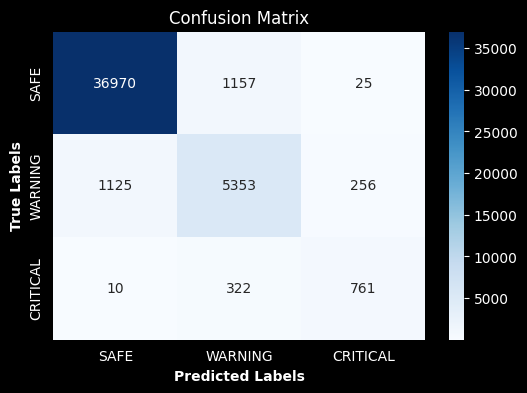

--- HISTORY ---
Epoch  | Tr.Loss  | Val.Loss | Prec. (S, W, C)    | Rec. (S, W, C)     | F1 (S, W, C)      
-----------------------------------------------------------------------------------------------
0      | 0.436    | 0.190    | (0.96, 0.76, 0.53) | (0.97, 0.66, 0.77) | (0.97, 0.71, 0.63)
1      | 0.354    | 0.162    | (0.96, 0.80, 0.76) | (0.98, 0.70, 0.62) | (0.97, 0.75, 0.68)
2      | 0.336    | 0.176    | (0.97, 0.75, 0.56) | (0.97, 0.70, 0.81) | (0.97, 0.73, 0.66)
3      | 0.324    | 0.172    | (0.97, 0.75, 0.58) | (0.97, 0.71, 0.74) | (0.97, 0.73, 0.65)
4      | 0.320    | 0.170    | (0.97, 0.75, 0.69) | (0.97, 0.76, 0.71) | (0.97, 0.75, 0.70)
5      | 0.314    | 0.152    | (0.97, 0.78, 0.74) | (0.97, 0.77, 0.62) | (0.97, 0.78, 0.68)
6      | 0.313    | 0.163    | (0.97, 0.77, 0.63) | (0.97, 0.74, 0.75) | (0.97, 0.75, 0.68)
7      | 0.305    | 0.155    | (0.96, 0.81, 0.71) | (0.98, 0.71, 0.69) | (0.97, 0.76, 0.70)
8      | 0.301    | 0.156    | (0.97, 0.78, 0.70) | (0.97, 0

In [84]:
training_history = dynamic_trainer.train()